# AAI614: Data Science & its Applications

*Notebook 7.1: Introducing Dask*

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-7/Saoud-Notebook7.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Source: NVIDIA

# Dask

Dask is not faster than pandas for a single file or for small size data.  It excels for multiple data as it uses lazy computaion. In this lab, we will learn how to use Dask to speed up computation under the correct conditions.

First, let's get these libraries loaded.

In [32]:
!pip install dask

import dask.dataframe as dd
import glob
import pandas as pd
import time
import urllib
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

## Using Dask versus Pandas

Neither pandas or cuDF can read in multiple CSV files directly with [read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html). In order to read multiple files into a DataFrame, we would need to loop through each file and append them together.

To see this, let's pull a couple more files from the [Water Level Website](https://tidesandcurrents.noaa.gov/stations.html?type=Water+Levels). This time, we will request a CSV and save it with the [urllib.request](https://docs.python.org/3/library/urllib.request.html).

In [33]:
"""
Download water level data (CSV) for multiple NOAA CO-OPS stations.

Uses only Python's standard library (urllib.request) to call the
CO-OPS Data Retrieval API:
    https://api.tidesandcurrents.noaa.gov/api/prod/datagetter

Docs: https://api.tidesandcurrents.noaa.gov/api/prod/
"""

import csv
import io
import time
import urllib.error
import urllib.parse
import urllib.request

BASE_URL = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"

# Any number of 7-character station IDs (see https://tidesandcurrents.noaa.gov/map)
STATION_IDS = [
    "8594900",  # Washington, DC
    "9410170",  # San Diego, CA
    "9414290",  # San Francisco, CA
    "8518750",  # The Battery, NY
    "8724580",  # Key West, FL
    "8725520",   # Fort Myers, FL
    "1612401",  # Pearl Harbor, HI
    "8761927",  # New Canal Station, LA
    "8443970",  # Boston, MA
    "8518750",  # The Battery, NY
    "8654467"   # USCG Station Hatteras, NC
]

# Shared query parameters for every station.
# product=water_level -> 6-minute preliminary/verified water levels
# datum is mandatory for all water level products.
COMMON_PARAMS = {
    "product": "water_level",
    "datum": "MLLW",
    "units": "english",
    "time_zone": "lst_ldt",
    "format": "csv",
    "application": "MyApp",  # replace with your name/org so NOAA can ID your traffic
    "begin_date": "20240101",
    "end_date": "20240107",
    # Alternative to begin_date/end_date:
    #   "date": "recent"        -> last 72 hours
    #   "begin_date": "...", "range": 48   -> 48 hours from begin_date
}

OUTPUT_DIR = "."          # where CSV files get written
REQUEST_DELAY_SECONDS = 1 # be polite to the API (throttling note in docs)
TIMEOUT_SECONDS = 30


def build_url(station_id: str) -> str:
    """Build the full datagetter URL for one station."""
    params = dict(COMMON_PARAMS)
    params["station"] = station_id
    query_string = urllib.parse.urlencode(params)
    return f"{BASE_URL}?{query_string}"


def fetch_station_csv(station_id: str) -> str:
    """Fetch raw CSV text for a single station. Raises on HTTP/URL errors."""
    url = build_url(station_id)
    req = urllib.request.Request(url, headers={"User-Agent": "python-urllib"})
    with urllib.request.urlopen(req, timeout=TIMEOUT_SECONDS) as response:
        raw_bytes = response.read()
    return raw_bytes.decode("utf-8")


def looks_like_error(csv_text: str) -> bool:
    """The API returns an error message (not real CSV rows) on bad requests."""
    first_line = csv_text.strip().splitlines()[0] if csv_text.strip() else ""
    return "error" in first_line.lower() and "," not in first_line


def save_csv(station_id: str, csv_text: str) -> str:
    """Write the CSV text to disk and return the file path."""
    file_path = f"{OUTPUT_DIR}/water_level_{station_id}.csv"
    with open(file_path, "w", newline="", encoding="utf-8") as f:
        f.write(csv_text)
    return file_path


def fetch_all(station_ids):
    """Fetch and save CSVs for every station; returns dict of results."""
    results = {}
    for i, station_id in enumerate(station_ids):
        print(f"Fetching station {station_id} ...")
        try:
            csv_text = fetch_station_csv(station_id)
        except urllib.error.HTTPError as e:
            print(f"  HTTP error {e.code} for station {station_id}: {e.reason}")
            results[station_id] = None
            continue
        except urllib.error.URLError as e:
            print(f"  Network error for station {station_id}: {e.reason}")
            results[station_id] = None
            continue

        if looks_like_error(csv_text):
            print(f"  API returned an error for station {station_id}: {csv_text.strip()}")
            results[station_id] = None
            continue

        path = save_csv(station_id, csv_text)
        row_count = sum(1 for _ in csv.reader(io.StringIO(csv_text))) - 1  # minus header
        print(f"  Saved {path} ({row_count} data rows)")
        results[station_id] = path

        # Space out requests to avoid API throttling, except after the last call
        if i < len(station_ids) - 1:
            time.sleep(REQUEST_DELAY_SECONDS)

    return results


if __name__ == "__main__":
    fetch_all(STATION_IDS)

Fetching station 8594900 ...
  Saved ./water_level_8594900.csv (1680 data rows)
Fetching station 9410170 ...
  Saved ./water_level_9410170.csv (1680 data rows)
Fetching station 9414290 ...
  Saved ./water_level_9414290.csv (1680 data rows)
Fetching station 8518750 ...
  Saved ./water_level_8518750.csv (1680 data rows)
Fetching station 8724580 ...
  Saved ./water_level_8724580.csv (1680 data rows)
Fetching station 8725520 ...
  Saved ./water_level_8725520.csv (1680 data rows)
Fetching station 1612401 ...
  Saved ./water_level_1612401.csv (1680 data rows)
Fetching station 8761927 ...
  Saved ./water_level_8761927.csv (1680 data rows)
Fetching station 8443970 ...
  Saved ./water_level_8443970.csv (1680 data rows)
Fetching station 8518750 ...
  Saved ./water_level_8518750.csv (1680 data rows)
Fetching station 8654467 ...
  Saved ./water_level_8654467.csv (1680 data rows)


We should now have a few `.csv` files in the `data` folder. When referencing these files, we could type out the paths of each of these files individually, but instead, we will use the [glob](https://docs.python.org/3/library/glob.html) library to programmatically do this for us. We can use `*` as a wild card to filter files that match our pattern specified like so:

In [34]:
file_paths = glob.glob("./*.csv")
file_paths = [file for file in file_paths if file != "data/numbers.csv"]
file_paths

['./water_level_9410170.csv',
 './water_level_8725520.csv',
 './water_level_1612401.csv',
 './water_level_8518750.csv',
 './water_level_8724580.csv',
 './water_level_8761927.csv',
 './water_level_9414290.csv',
 './water_level_8594900.csv',
 './water_level_8443970.csv',
 './water_level_8654467.csv']

Each path starts with `data`, ends with `.csv`, and the `*` indicates to pick up anything in between. Let's set up a for loop to see how long it takes to read all of these files. Run the block **twice** to see how much faster cuDF is after it has been initialized.

In [35]:
usecols = [0, 1, 2, 4, 5]  # Column names are different when pulling csv directly


def read_all(library, file_paths):
    df_list = []
    for file in file_paths:
        df = library.read_csv(
            file, index_col=None, header=None, usecols=usecols, skiprows=1
        )
        df_list.append(df)
    return library.concat(df_list, axis=0, ignore_index=True) if df_list else []  # Return the first DataFrame if no files were read



df_cpu = read_all(pd, file_paths)

In [36]:
df_cpu

,0,1,2,4,5
0,2024-01-01 00:00,4.251,0.036,0,0
1,2024-01-01 00:06,4.287,0.030,0,0
2,2024-01-01 00:12,4.307,0.030,0,0
3,2024-01-01 00:18,4.356,0.043,0,0
4,2024-01-01 00:24,4.379,0.023,0,0
...,...,...,...,...,...
16795,2024-01-07 23:30,0.938,0.075,0,0
16796,2024-01-07 23:36,0.948,0.079,0,0
16797,2024-01-07 23:42,0.945,0.072,0,0
16798,2024-01-07 23:48,0.945,0.079,0,0


Since Dask is made to be parallel, we do not need a for loop. It can read multiple files natively.

The below code shows how to read data in parallel. This only sets up the process to read the files. we need to force Dask to *compute*

In [37]:
ddf_cpu = dd.read_csv(file_paths, usecols=usecols, header=0, skipinitialspace=True)

ddf_cpu.compute()

,Date Time,Water Level,Sigma,F,R
0,2024-01-01 00:00,4.251,0.036,0,0
1,2024-01-01 00:06,4.287,0.030,0,0
2,2024-01-01 00:12,4.307,0.030,0,0
3,2024-01-01 00:18,4.356,0.043,0,0
4,2024-01-01 00:24,4.379,0.023,0,0
...,...,...,...,...,...
1675,2024-01-07 23:30,0.938,0.075,0,0
1676,2024-01-07 23:36,0.948,0.079,0,0
1677,2024-01-07 23:42,0.945,0.072,0,0
1678,2024-01-07 23:48,0.945,0.079,0,0


Let's sample our data to confirm it had been read correctly. This time, we will only be working with the first three columns of data.

In [38]:
%%time
ddf_cpu.head()

CPU times: user 19.9 ms, sys: 117 µs, total: 20 ms
Wall time: 25.8 ms


,Date Time,Water Level,Sigma,F,R
0,2024-01-01 00:00,4.251,0.036,0,0
1,2024-01-01 00:06,4.287,0.030,0,0
2,2024-01-01 00:12,4.307,0.030,0,0
3,2024-01-01 00:18,4.356,0.043,0,0
4,2024-01-01 00:24,4.379,0.023,0,0


How can Dask do this faster than regular pandas or cuDF? Under the hood, Dask is building a system of operations called a DAG. We can view this DAG with the [visualize](https://docs.dask.org/en/latest/graphviz.html) method.

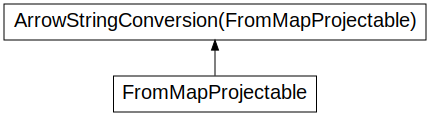

In [39]:
ddf_cpu.visualize()

Our experiment showed that Dask is most useful when working with many CSV files rather than a single small dataset. Pandas read the files sequentially and took longer, while Dask handled the same input in parallel by building a task graph and delaying computation until necessary. The results support the idea that Dask improves performance for large-scale data workflows, but it is not necessarily faster for small datasets because the overhead of setup can outweigh the benefits. Overall, Dask is a strong choice for scalable analytics.

Plotting 10 files...


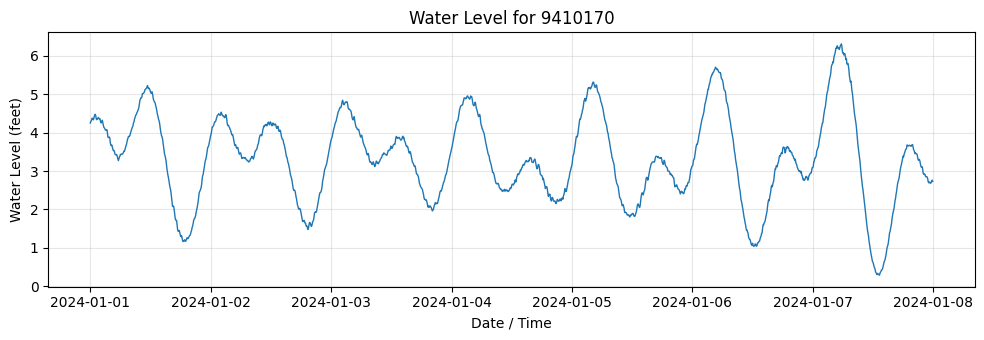

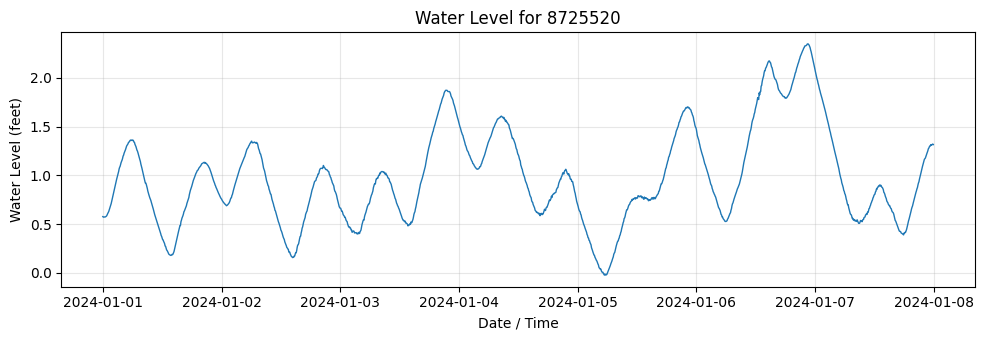

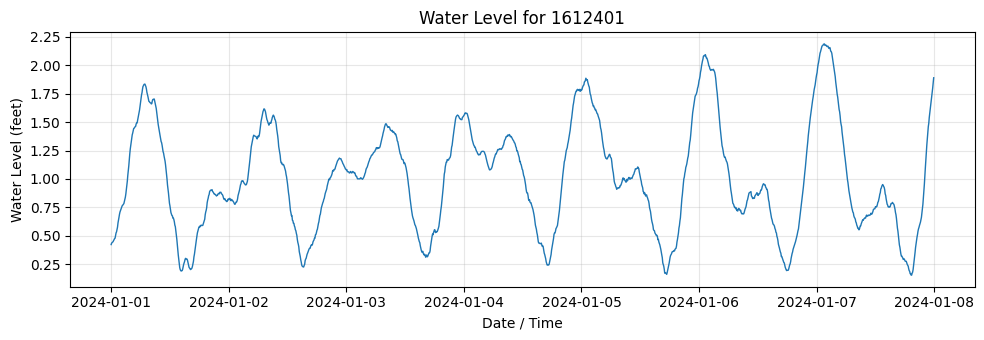

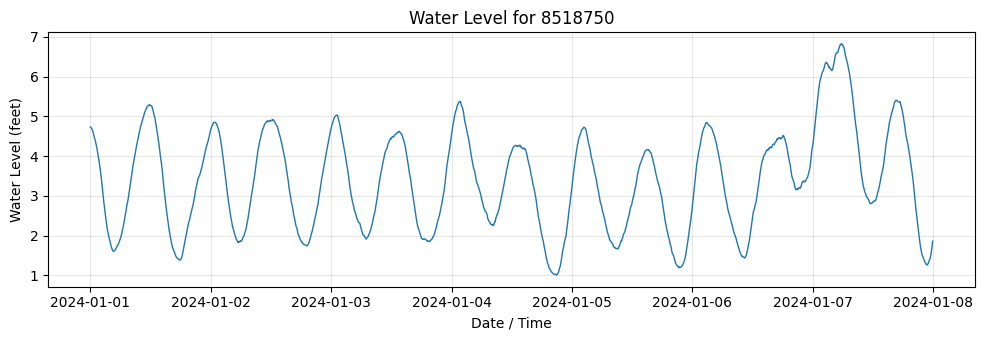

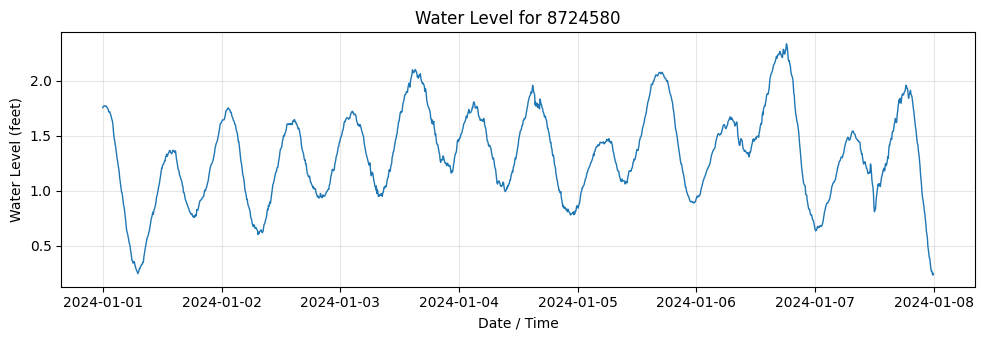

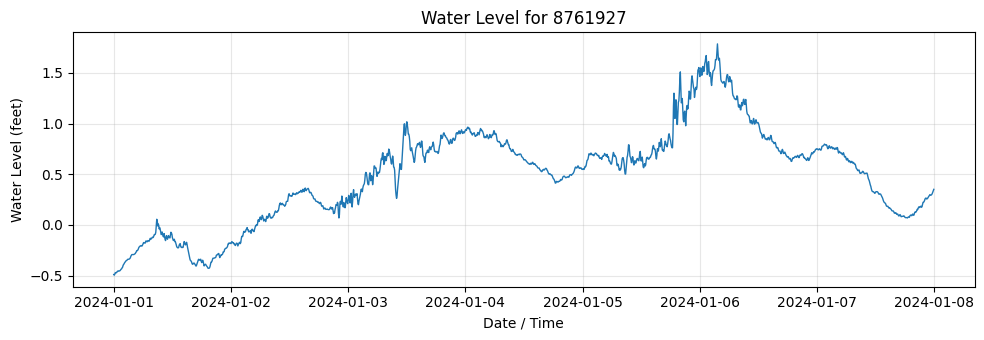

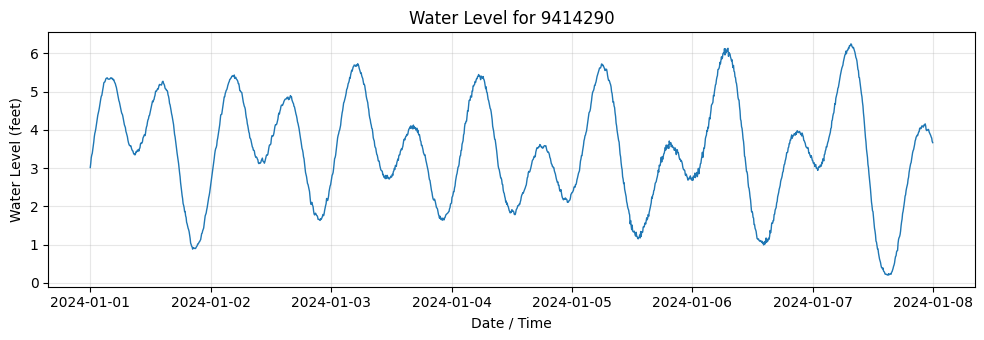

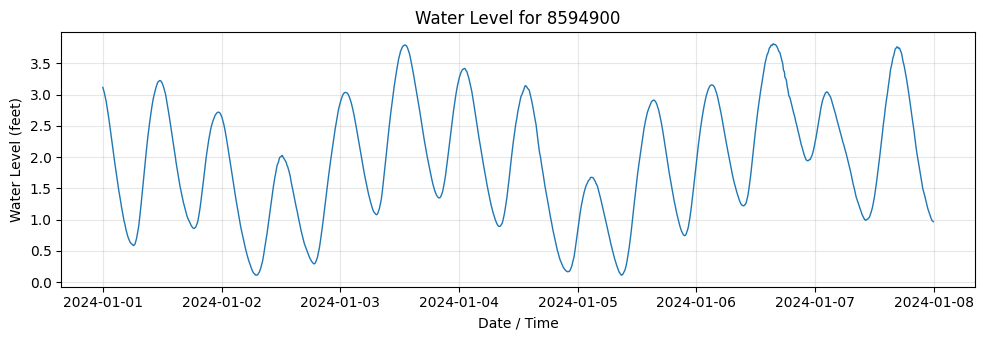

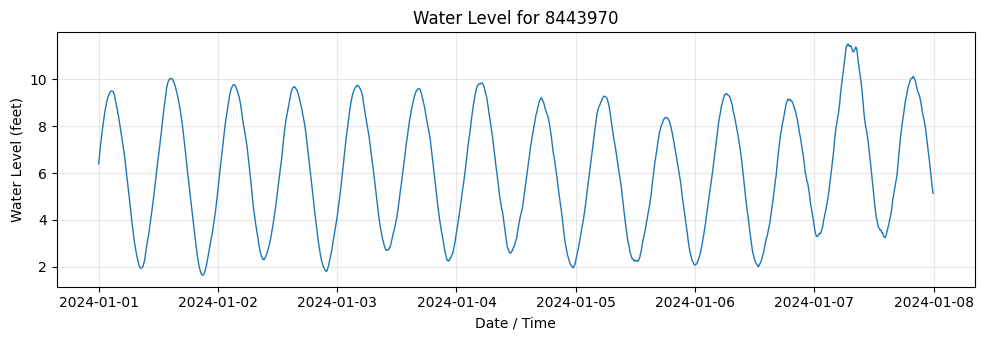

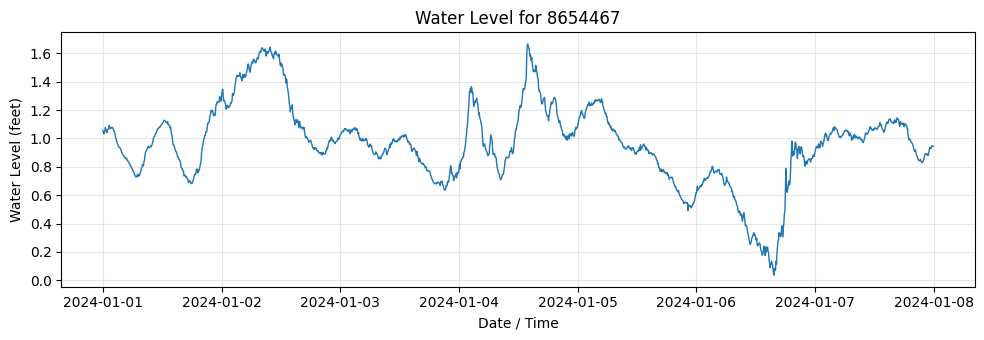

In [40]:
import os
import matplotlib.pyplot as plt

print(f"Plotting {len(file_paths)} files...")


def plot_water_level(csv_path):
    df = pd.read_csv(
        csv_path,
        header=None,
        skiprows=1,
        usecols=[0, 1],
        names=["datetime", "water_level"],
        parse_dates=["datetime"],
    )
    df = df.sort_values("datetime")

    plt.figure(figsize=(10, 3.5))
    plt.plot(df["datetime"], df["water_level"], color="tab:blue", linewidth=1)
    plt.title(
        f"Water Level for {os.path.basename(csv_path).replace('water_level_', '').replace('.csv', '')}"
    )
    plt.xlabel("Date / Time")
    plt.ylabel("Water Level (feet)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


for path in file_paths:
    plot_water_level(path)